In [1]:
# python
import uproot
import vector
import numpy as np
import sys
import importlib
# columnar analysis
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
from coffea import processor
import awkward as ak
from dask.distributed import Client, performance_report
# local
sidm_path = str(sys.path[0]).split("/sidm")[0]
if sidm_path not in sys.path: sys.path.insert(1, sidm_path)
from sidm.tools import sidm_processor, utilities, scaleout, selection, llpnanoaodschema
#from sidm.tools import llpnanoaodschema_0726 as llpnanoaodschema
# always reload local modules to pick up changes during development
importlib.reload(sidm_processor)
importlib.reload(utilities)
importlib.reload(scaleout)
importlib.reload(selection)
importlib.reload(llpnanoaodschema)
# plotting
import matplotlib.pyplot as plt
utilities.set_plot_style()
from hist import Hist

/tmp/ipykernel_239/1742796110.py:8: DeprecationWarning: NanoEventsFactory.from_root() behavior has changed.
    The default behavior is that now it reads the input root file using
    the newly developed virtual arrays backend of awkward instead of dask.
    The backend choice is controlled by the `mode` argument of the method
    which can be set to "eager", "virtual", or "dask".
    The new default is "virtual" while the `delayed` argument has been removed.
    The old `delayed=True` is now equivalent to `mode="dask"`.
    The old `delayed=False` is now equivalent to `mode="eager"`.
    
  from coffea.nanoevents import NanoEventsFactory, NanoAODSchema


In [2]:
samples = [
    'DYJetsToMuMu_M10to50',
]
fileset = utilities.make_fileset(samples, "llpNanoAOD_v2", max_files=1, location_cfg="backgrounds.yaml")

runner = processor.Runner(
    executor=processor.IterativeExecutor(),
    #executor=processor.DaskExecutor(client=client),
    #schema=NanoAODSchema,
    #schema=llpnanoaodschema.NanoAODSchema,
    schema=llpnanoaodschema.LLPNanoAODSchema,
    #maxchunks=1,
    skipbadfiles=True,
)

channels = [
   "baseNoTriggerNoLjNoLjsource",
]

p = sidm_processor.SidmProcessor(
    channels,
    ["genMu_base"],
    verbose=True,
)


out = {}
for i, sample in enumerate(samples):
    print(f"Processing {sample}")
    fileset_one_sample = {samples[i]:fileset.get(samples[i])}
    output = runner.run(fileset_one_sample, treename='Events', processor_instance=p)
    #Add this sample's output to the out variable
    out[sample] = output["out"][sample]

Output()

Processing DYJetsToMuMu_M10to50


Output()

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_electronIdx => Electron
  warnings.warn(

/usr/local/lib/python3.12/site-packages/coffea/nanoevents/schemas/nanoaod.py:264: RuntimeWarning: Missing 
cross-reference index for LowPtElectron_photonIdx => Photon
  warnings.warn(

...

Applying genEs status 1

Warning: Did not find cuts for muons in the config. No cuts will be applied to the nested objects

Warning: Did not find cuts for dsaMuons in the config. No cuts will be applied to the nested objects

#--------------------------------------------------------------------------
#                         FastJet release 3.4.3
#                 M. Cacciari, G.P. Salam and G. Soyez                  
#     A software package for jet finding and analysis at colliders      
#                           http://fastjet.fr                           
#	                                                                      
# Please cite EPJC72(2012)1896 [arXiv:1111.6097] if you use this package
# for scientific work and optionally PLB641(2006)57 [hep-ph/0512210].   
#                                                                       
# FastJet is provided without warranty under the GNU GPL v2 or higher.  
# It uses T. Chan's closest pair algorithm, S. Fortune's Voronoi code,
# CGAL and 3rd party plugin jet algorithms. See COPYING file for details.
#--------------------------------------------------------------------------


Applying cut: PV filter

Text(0.5, 1.07, 'DYJetsToMuMu_M10to50')

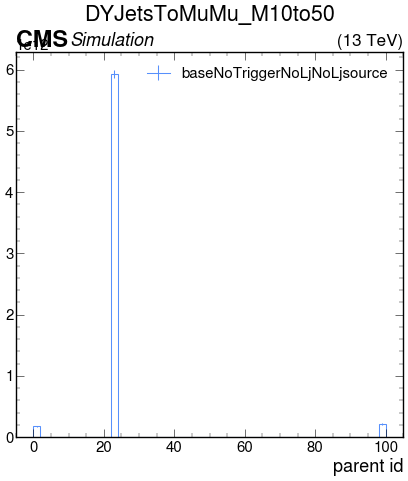

In [6]:
channel1 = 0
utilities.plot(out[samples[0]]["hists"]["genMus_parent"][channels[channel1], ::2j],label=channels[channel1])
#plt.yscale("log")
plt.legend()
plt.title(samples[0],y=1.07)

In [5]:
#Fill in the path to individual llpNanoAOD files here
#file_path = "SIDM/Student_Notebooks/"
#file_names  = ["ffNtuple_2Mu2E_500_1p2_9p6.root","ffNtuple_2Mu2E_200_1p2_4p8.root","ffNtuple_2Mu2E_500_5_40.root"]
file_path = "root://xcache//store/group/lpcmetx/SIDM/Backgrounds/2018_v2/DYJetsToMuMu_M-10to50_H2ErratumFix_TuneCP5_13TeV-powhegMiNNLO-pythia8-photos/"
file_names = [
    "output_1.root",
    "output_2.root",
    "output_3.root",
    "output_4.root",
    "output_5.root",
    "output_6.root",
]


branches_dict = {}

for file_name in file_names:
    print("Opening ",file_path+file_name)
    temp_file = uproot.open(file_path+file_name)
    tree = temp_file['Events']
    #Load all the branches into memory and store in branches_dict (this is slow, and could be done in a 
    #"lazy" way to only read the arrays that we end up using, but I'm too lazy to be lazy)
    branches_dict[file_name] = tree.arrays()

Opening  root://xcache//store/group/lpcmetx/SIDM/Backgrounds/2018_v2/DYJetsToMuMu_M-10to50_H2ErratumFix_TuneCP5_13TeV-powhegMiNNLO-pythia8-photos/output_1.root
Opening  root://xcache//store/group/lpcmetx/SIDM/Backgrounds/2018_v2/DYJetsToMuMu_M-10to50_H2ErratumFix_TuneCP5_13TeV-powhegMiNNLO-pythia8-photos/output_2.root
Opening  root://xcache//store/group/lpcmetx/SIDM/Backgrounds/2018_v2/DYJetsToMuMu_M-10to50_H2ErratumFix_TuneCP5_13TeV-powhegMiNNLO-pythia8-photos/output_3.root
Opening  root://xcache//store/group/lpcmetx/SIDM/Backgrounds/2018_v2/DYJetsToMuMu_M-10to50_H2ErratumFix_TuneCP5_13TeV-powhegMiNNLO-pythia8-photos/output_4.root
Opening  root://xcache//store/group/lpcmetx/SIDM/Backgrounds/2018_v2/DYJetsToMuMu_M-10to50_H2ErratumFix_TuneCP5_13TeV-powhegMiNNLO-pythia8-photos/output_5.root
Opening  root://xcache//store/group/lpcmetx/SIDM/Backgrounds/2018_v2/DYJetsToMuMu_M-10to50_H2ErratumFix_TuneCP5_13TeV-powhegMiNNLO-pythia8-photos/output_6.root


In [3]:
#Explore the branches in the files
tree.keys(filter_name="GenPart_*")

['GenPart_eta',
 'GenPart_mass',
 'GenPart_phi',
 'GenPart_pt',
 'GenPart_genPartIdxMother',
 'GenPart_pdgId',
 'GenPart_status',
 'GenPart_statusFlags',
 'GenPart_vx',
 'GenPart_vy',
 'GenPart_vz',
 'GenPart_px',
 'GenPart_py',
 'GenPart_pz']

Processing  output_1.root
Processing  output_2.root
Processing  output_3.root
Processing  output_4.root
Processing  output_5.root
Processing  output_6.root


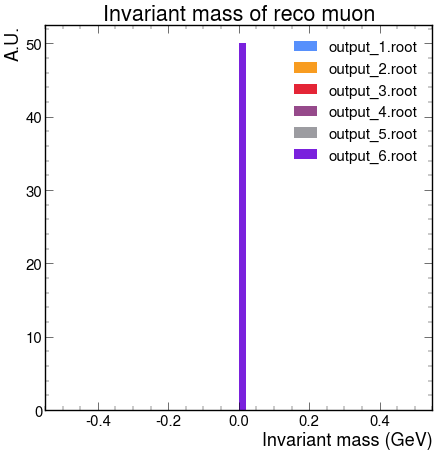

In [16]:
#Plot the invariant mass of the reconstructed muon pair (should peak at the dark photon mass)

for file_name in file_names:
    print("Processing ",file_name)
    branches = branches_dict[file_name]
    
    #Create a vector object for the muons
    pdgId = branches["GenPart_pdgId"]
    motherIdx = branches["GenPart_genPartIdxMother"]

  
    
    muon_mass = branches['GenPart_mass']
    muon_pt = branches['GenPart_pt']
    muon_eta = branches['GenPart_eta']
    muon_phi = branches['GenPart_phi']

    
    #mother_pdgId = ak.where(muon_motherIdx >= 0, pdgId[muon_motherIdx], -1)

    muons = vector.zip({
                        "pt": muon_pt,
                        "eta": muon_eta,
                        "phi": muon_phi,
                        "mass": muon_mass,
                        "id": pdgId,
                        "mother": motherIdx,
                      
    })

    #Apply quality cuts to muons (could add more here)
    good_muon_mask = (muons.mother == 23) & (muons.id == 13)
    
    #Apply the mask
    good_muons = muons[good_muon_mask]
 
    
   
    plt.hist(ak.flatten(good_muons.mass), bins=50, label = file_name,density=True)
plt.xlabel('Invariant mass (GeV)')
plt.ylabel('A.U.')
plt.title('Invariant mass of reco muon')
plt.legend(loc = 'upper right')


Processing  output_1.root


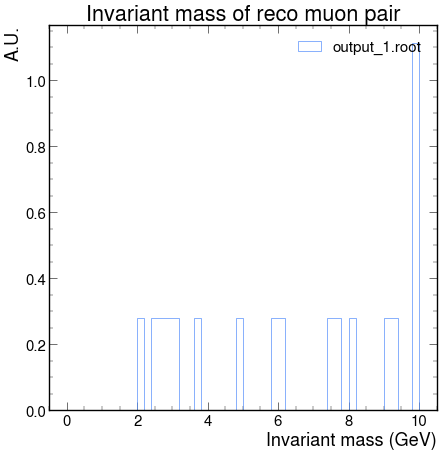

In [6]:
#Plot the invariant mass of the reconstructed muon pair (should peak at the dark photon mass)

for file_name in file_names:
    print("Processing ",file_name)
    branches = branches_dict[file_name]
    
    #Create a vector object for the muons
    pdgId = branches["GenPart_pdgId"]
    
    muon_p4 = vector.zip({"pt": branches['Muon_pt'],
                          "eta": branches['Muon_eta'],
                          "phi": branches['Muon_phi'],
                          "mass": branches['Muon_mass']})
    
    #Apply quality cuts to muons (could add more here)
    good_muon_mask = (muon_p4.pt > 5) & (abs(muon_p4.eta) < 2.4) #muon level mask
    
    #Apply the mask
    good_muons = muon_p4[good_muon_mask]
    
    #Select events with at least two good muons
    two_muons_mask = ak.count(good_muons.pt,1) >= 2 #event level mask
    two_muons_p4 = good_muons[two_muons_mask]
    
    first_muon_p4 = two_muons_p4[:, 0]
    second_muon_p4 = two_muons_p4[:, 1]
    muon_sum_p4 = first_muon_p4 + second_muon_p4 #event level quantity
    two_muons_charges = branches['Muon_charge'][two_muons_mask]
    opposite_sign_muons_mask = two_muons_charges[:, 0] != two_muons_charges[:, 1] #event level mask
    dimuon_p4 = muon_sum_p4[opposite_sign_muons_mask]
    plt.hist(dimuon_p4.mass, bins=50, range=(0, 10), label = file_name,histtype='step',density=True)
plt.xlabel('Invariant mass (GeV)')
plt.ylabel('A.U.')
plt.title('Invariant mass of reco muon pair')
plt.legend(loc = 'upper right')


In [59]:
#Plot the invariant mass of the reconstructed muon pair (should peak at the dark photon mass)

for file_name in file_names:
    print("Processing ",file_name)
    branches = branches_dict[file_name]
    
    #Create a vector object for the muons
    muon_p4 = vector.zip({"pt": branches['Muon_pt'],
                          "eta": branches['Muon_eta'],
                          "phi": branches['Muon_phi'],
                          "mass": branches['Muon_mass']})

for i in muon.mother():
    print(i)

Processing  output_1.root


AttributeError: no field named 'mother'